<a href="https://colab.research.google.com/github/Abdullahcys10/MachineLearning6my2/blob/main/lab11/02_Credit_Card_Customer_Segmentation_Assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

ARTI308 - Machine Learning

# Credit Card Customer Segmentation Project

In this project, you will use K-Means clustering to segment [credit card customers](https://www.kaggle.com/datasets/arjunbhasin2013/ccdata/data) based on their usage behavior. This is an unsupervised learning problem because the dataset does not contain a target label for customer groups.

You will use the `CC_GENERAL.csv` dataset.

## About the Dataset

The dataset contains customer-level credit card usage behavior. Each row represents one credit card holder, and the columns describe different behavioral variables such as balance, purchases, cash advance, payments, and tenure. The goal is to group similar customers together so that the company can understand different customer segments and design better marketing strategies.

## Import Libraries

**Import the libraries you need for data analysis, visualization, preprocessing, clustering, and evaluation.**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

import warnings
warnings.filterwarnings('ignore')

%matplotlib inline

## Get the Data

**Read the `CC_GENERAL.csv` file and save it in a dataframe called `df`.**

In [2]:
df = pd.read_csv('CC_GENERAL.csv')

**Check the first five rows of the dataset.**

In [3]:
df.head()

,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,C10001,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,C10002,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,C10003,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,C10004,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12
4,C10005,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12


**Check the shape of the dataset.**

In [4]:
df.shape

(8950, 18)

**Check basic information about the dataset using `info()`.**

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8950 entries, 0 to 8949
Data columns (total 18 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   CUST_ID                           8950 non-null   object 
 1   BALANCE                           8950 non-null   float64
 2   BALANCE_FREQUENCY                 8950 non-null   float64
 3   PURCHASES                         8950 non-null   float64
 4   ONEOFF_PURCHASES                  8950 non-null   float64
 5   INSTALLMENTS_PURCHASES            8950 non-null   float64
 6   CASH_ADVANCE                      8950 non-null   float64
 7   PURCHASES_FREQUENCY               8950 non-null   float64
 8   ONEOFF_PURCHASES_FREQUENCY        8950 non-null   float64
 9   PURCHASES_INSTALLMENTS_FREQUENCY  8950 non-null   float64
 10  CASH_ADVANCE_FREQUENCY            8950 non-null   float64
 11  CASH_ADVANCE_TRX                  8950 non-null   int64  
 12  PURCHA

**Check summary statistics using `describe()`.**

In [6]:
df.describe()

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
count,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8949.000000,8950.000000,8637.000000,8950.000000,8950.000000
mean,1564.474828,0.877271,1003.204834,592.437371,411.067645,978.871112,0.490351,0.202458,0.364437,0.135144,3.248827,14.709832,4494.449450,1733.143852,864.206542,0.153715,11.517318
std,2081.531879,0.236904,2136.634782,1659.887917,904.338115,2097.163877,0.401371,0.298336,0.397448,0.200121,6.824647,24.857649,3638.815725,2895.063757,2372.446607,0.292499,1.338331
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,50.000000,0.000000,0.019163,0.000000,6.000000
25%,128.281915,0.888889,39.635000,0.000000,0.000000,0.000000,0.083333,0.000000,0.000000,0.000000,0.000000,1.000000,1600.000000,383.276166,169.123707,0.000000,12.000000
50%,873.385231,1.000000,361.280000,38.000000,89.000000,0.000000,0.500000,0.083333,0.166667,0.000000,0.000000,7.000000,3000.000000,856.901546,312.343947,0.000000,12.000000
75%,2054.140036,1.000000,1110.130000,577.405000,468.637500,1113.821139,0.916667,0.300000,0.750000,0.222222,4.000000,17.000000,6500.000000,1901.134317,825.485459,0.142857,12.000000
max,19043.138560,1.000000,49039.570000,40761.250000,22500.000000,47137.211760,1.000000,1.000000,1.000000,1.500000,123.000000,358.000000,30000.000000,50721.483360,76406.207520,1.000000,12.000000


## Data Cleaning

The column `CUST_ID` is an identification column. It is not useful for clustering because it does not describe customer behavior.

**Drop the `CUST_ID` column from the dataframe.**

In [7]:
df.drop('CUST_ID', axis=1, inplace=True)

**Check the missing values in each column.**

In [8]:
df.isnull().sum()

,0
BALANCE,0
BALANCE_FREQUENCY,0
PURCHASES,0
ONEOFF_PURCHASES,0
INSTALLMENTS_PURCHASES,0
CASH_ADVANCE,0
PURCHASES_FREQUENCY,0
ONEOFF_PURCHASES_FREQUENCY,0
PURCHASES_INSTALLMENTS_FREQUENCY,0
CASH_ADVANCE_FREQUENCY,0


Some columns may contain missing values.

Hint: You can handle missing values by either:
- filling them with the mean value
- or dropping the rows that contain missing values

For this project, use mean imputation.

**Fill the missing values with the mean of each column.**

In [9]:
df.fillna(df.mean(), inplace=True)

**Check the missing values again to make sure they were handled.**

In [10]:
df.isnull().sum()

,0
BALANCE,0
BALANCE_FREQUENCY,0
PURCHASES,0
ONEOFF_PURCHASES,0
INSTALLMENTS_PURCHASES,0
CASH_ADVANCE,0
PURCHASES_FREQUENCY,0
ONEOFF_PURCHASES_FREQUENCY,0
PURCHASES_INSTALLMENTS_FREQUENCY,0
CASH_ADVANCE_FREQUENCY,0


## Exploratory Data Analysis

Before applying clustering, it is important to understand the data.

**Create histograms for the numerical columns.**

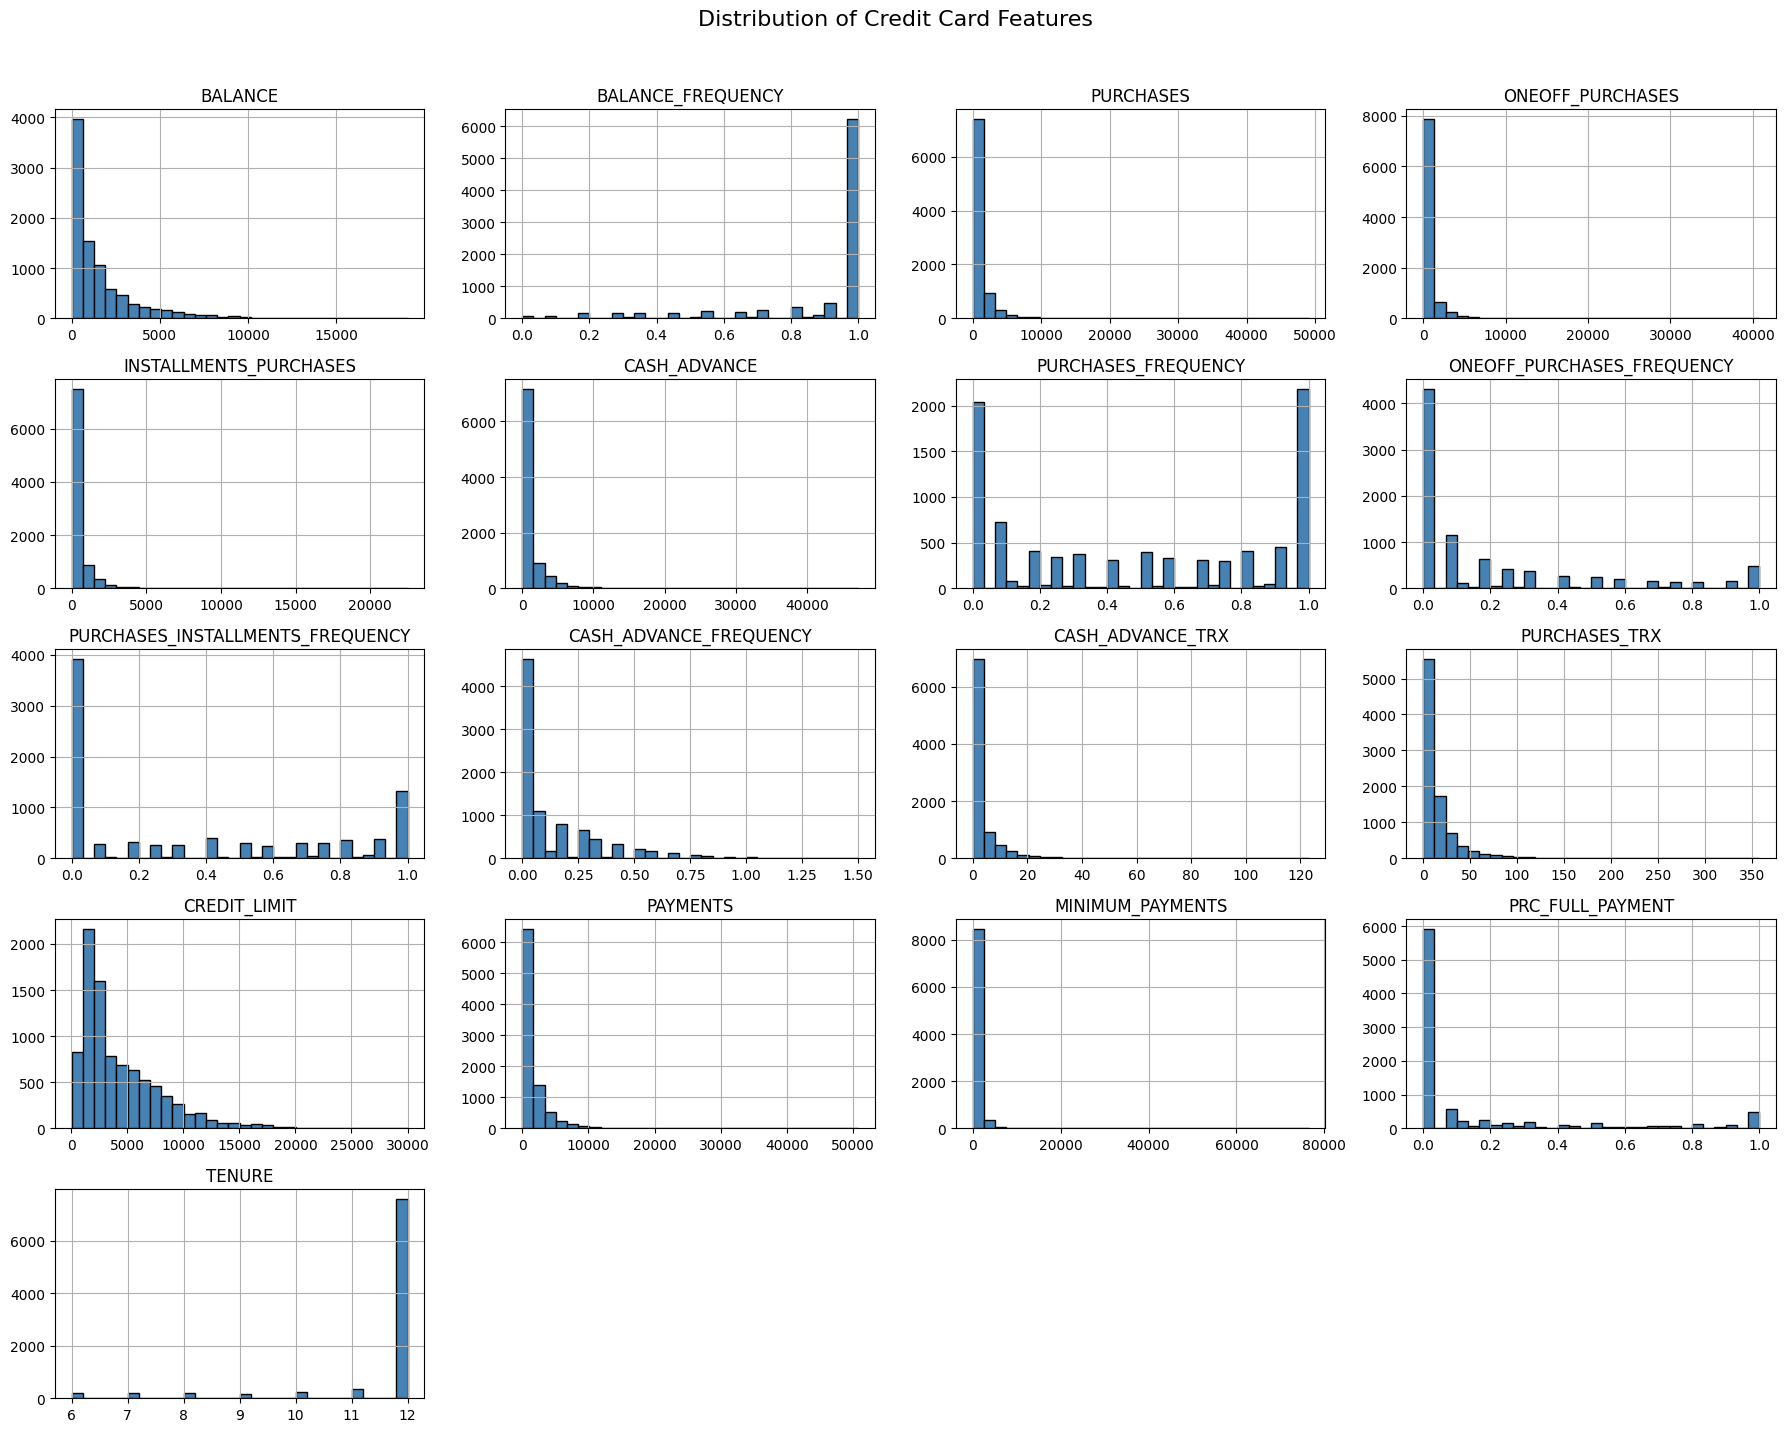

In [11]:
df.hist(figsize=(18, 14), bins=30, color='steelblue', edgecolor='black')
plt.suptitle('Distribution of Credit Card Features', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

**Create a correlation heatmap to understand relationships between the features.**

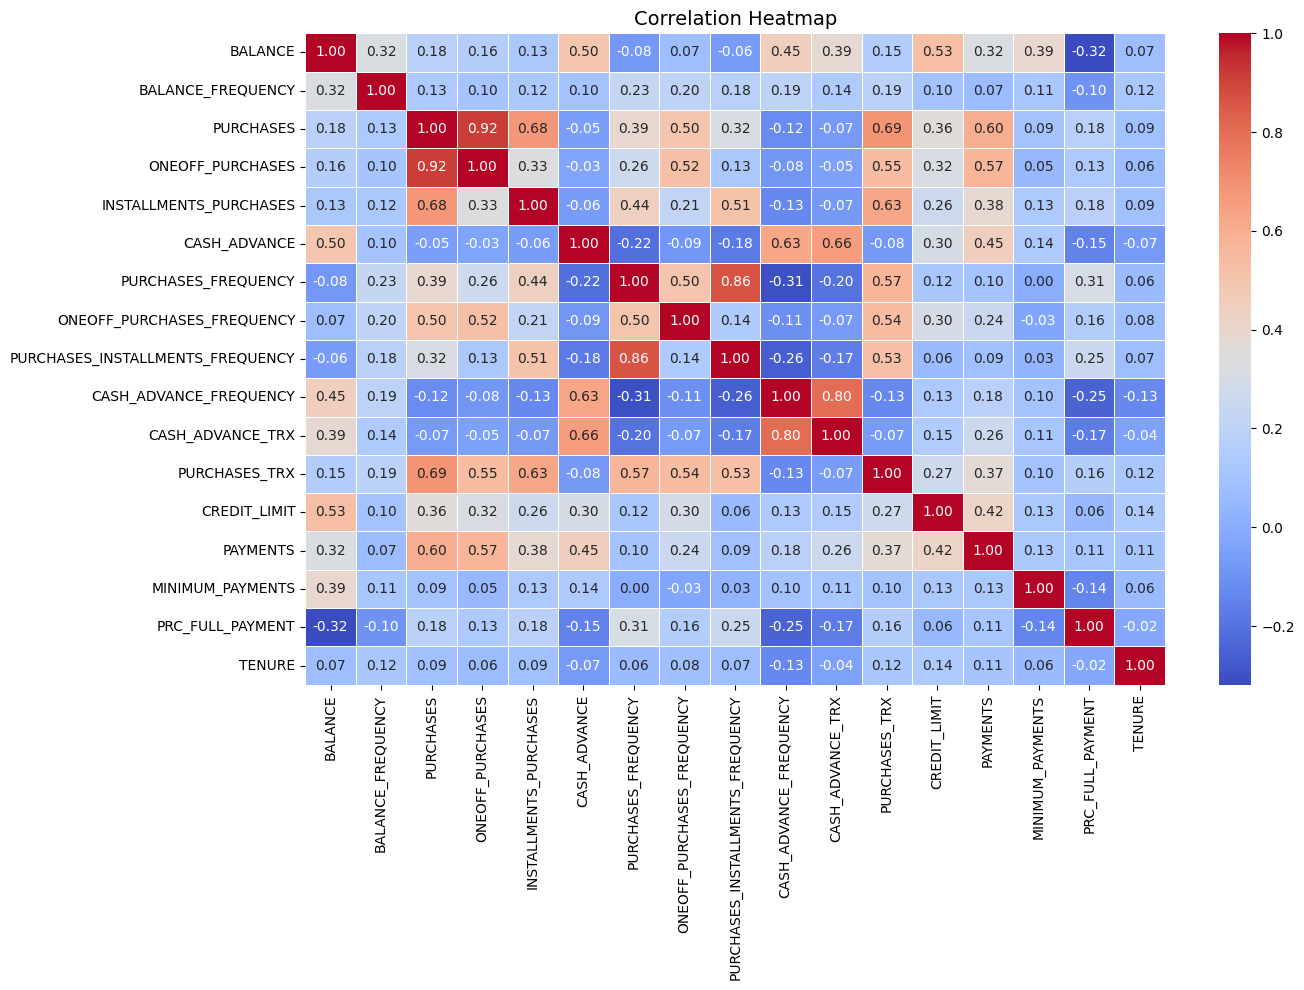

In [12]:
plt.figure(figsize=(14, 10))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap', fontsize=14)
plt.tight_layout()
plt.show()

**Create a scatter plot between `BALANCE` and `PURCHASES`.**

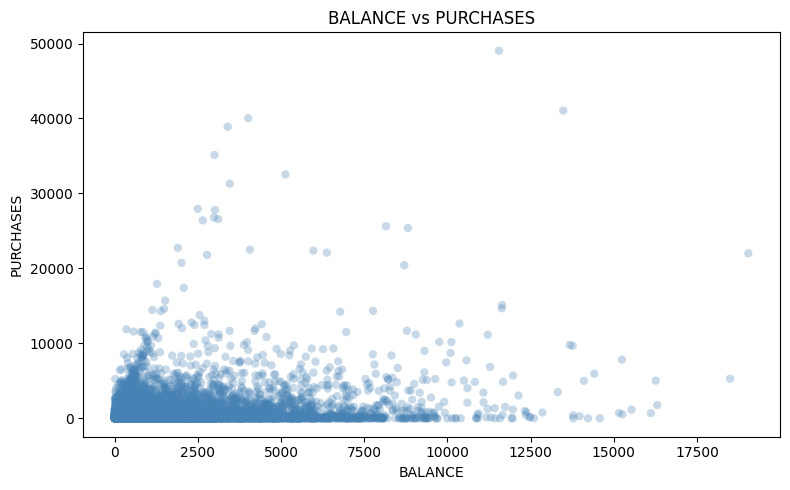

In [13]:
plt.figure(figsize=(8, 5))
plt.scatter(df['BALANCE'], df['PURCHASES'], alpha=0.3, color='steelblue', edgecolors='none')
plt.xlabel('BALANCE')
plt.ylabel('PURCHASES')
plt.title('BALANCE vs PURCHASES')
plt.tight_layout()
plt.show()

**Create a scatter plot between `BALANCE` and `CASH_ADVANCE`.**

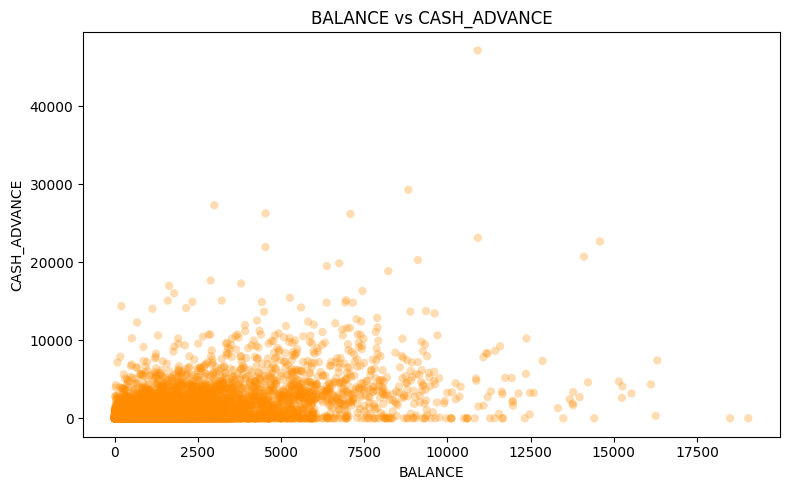

In [14]:
plt.figure(figsize=(8, 5))
plt.scatter(df['BALANCE'], df['CASH_ADVANCE'], alpha=0.3, color='darkorange', edgecolors='none')
plt.xlabel('BALANCE')
plt.ylabel('CASH_ADVANCE')
plt.title('BALANCE vs CASH_ADVANCE')
plt.tight_layout()
plt.show()

## Feature Scaling

K-Means is a distance-based algorithm. Therefore, feature scaling is very important.

The features in this dataset have very different ranges. For example, `BALANCE`, `PURCHASES`, and `CREDIT_LIMIT` may have large values, while frequency columns are between 0 and 1.

**Use StandardScaler to scale the data. Save the scaled data in a variable called `X_scaled`.**

In [15]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

## Choosing K Intuitively

Choosing K is one of the most difficult parts of K-Means.

Since this dataset has many features, it is not easy to visually see the clusters directly.

However, we can still compare different K values using the elbow method and silhouette score.

## Elbow Method

**Create a loop that fits K-Means models for K values from 1 to 10. Save the inertia values in a list called `inertia_values`.**

In [16]:
inertia_values = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia_values.append(kmeans.inertia_)

**Plot the elbow curve.**

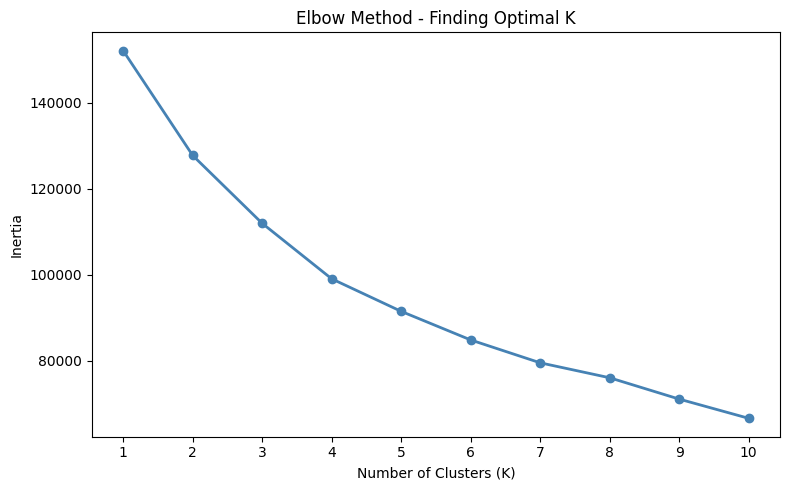

In [17]:
plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), inertia_values, marker='o', color='steelblue', linewidth=2)
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.title('Elbow Method - Finding Optimal K')
plt.xticks(range(1, 11))
plt.tight_layout()
plt.show()

**Output Interpretation**

Look at the elbow curve and try to identify where the decrease in inertia starts to slow down.

That point can suggest a reasonable value for K.

## Silhouette Score

The silhouette score helps evaluate how well-separated the clusters are.

**Create a loop that calculates the silhouette score for K values from 2 to 10. Save the scores in a list called `silhouette_scores`.**

In [18]:
silhouette_scores = []

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    silhouette_scores.append(score)

**Plot the silhouette scores.**

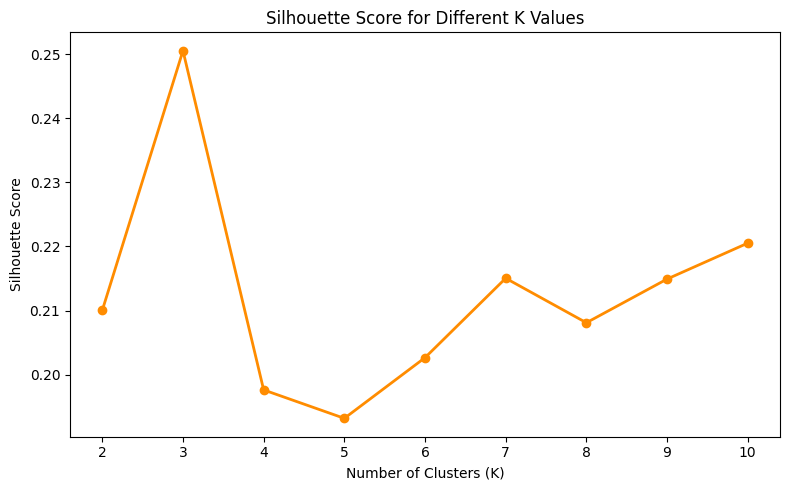

In [19]:
plt.figure(figsize=(8, 5))
plt.plot(range(2, 11), silhouette_scores, marker='o', color='darkorange', linewidth=2)
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score for Different K Values')
plt.xticks(range(2, 11))
plt.tight_layout()
plt.show()

**Create a table showing each K value and its silhouette score.**

In [20]:
silhouette_table = pd.DataFrame({
    'K': range(2, 11),
    'Silhouette Score': [round(s, 4) for s in silhouette_scores]
})
silhouette_table

,K,Silhouette Score
0,2,0.2100
1,3,0.2506
2,4,0.1976
3,5,0.1932
4,6,0.2026
5,7,0.2150
6,8,0.2081
7,9,0.2149
8,10,0.2205


**Output Interpretation**

A higher silhouette score usually means better clustering.

However, do not rely only on the highest value. Also consider whether the chosen K makes sense for customer segmentation.

## Create the Final K-Means Model

**Based on the elbow curve and silhouette scores, choose a final K value. Then train a final K-Means model.**

Use `random_state=42` and `n_init=10`.

In [21]:
# K=3 is chosen based on:
# 1. The elbow curve shows a noticeable bend around K=3
# 2. K=3 produces the highest silhouette score (0.2506) among all tested values
# 3. Three segments make business sense for customer marketing strategy

final_k = 3

final_kmeans = KMeans(n_clusters=final_k, random_state=42, n_init=10)
final_kmeans.fit(X_scaled)

KMeans(n_clusters=3, n_init=10, random_state=42)

**Add the final cluster labels to the original dataframe in a new column called `Cluster`.**

In [22]:
df['Cluster'] = final_kmeans.labels_

**Check the first five rows after adding the cluster labels.**

In [23]:
df.head()

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE,Cluster
0,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12,2
1,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12,0
2,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12,2
3,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,864.206542,0.000000,12,2
4,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12,2


## Cluster Analysis

Now we need to understand what each cluster means.

**Create a summary table using `groupby()` to show the mean values of each feature for each cluster.**

In [24]:
cluster_summary = df.groupby('Cluster').mean().round(2)
cluster_summary

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
Cluster,,,,,,,,,,,,,,,,,
0,3989.33,0.96,384.53,248.72,135.89,3869.86,0.23,0.11,0.14,0.45,12.39,5.61,6682.96,3018.91,1795.69,0.03,11.35
1,2220.00,0.98,4268.52,2717.83,1551.18,458.42,0.95,0.67,0.74,0.06,1.53,56.47,7733.97,4151.28,1224.54,0.30,11.92
2,799.70,0.84,505.53,253.12,252.73,329.87,0.47,0.13,0.35,0.07,1.21,8.65,3269.79,909.73,548.53,0.16,11.48


**Check how many customers are in each cluster.**

In [25]:
df['Cluster'].value_counts().sort_index()

,count
Cluster,
0,1596
1,1235
2,6119


## Visualizing the Final Clusters

Since the dataset has many features, we will use PCA to reduce the data into two components only for visualization.

This visualization does not replace the original clustering. It only helps us see the clusters in a 2D plot.

**Use PCA with 2 components and plot the clusters.**

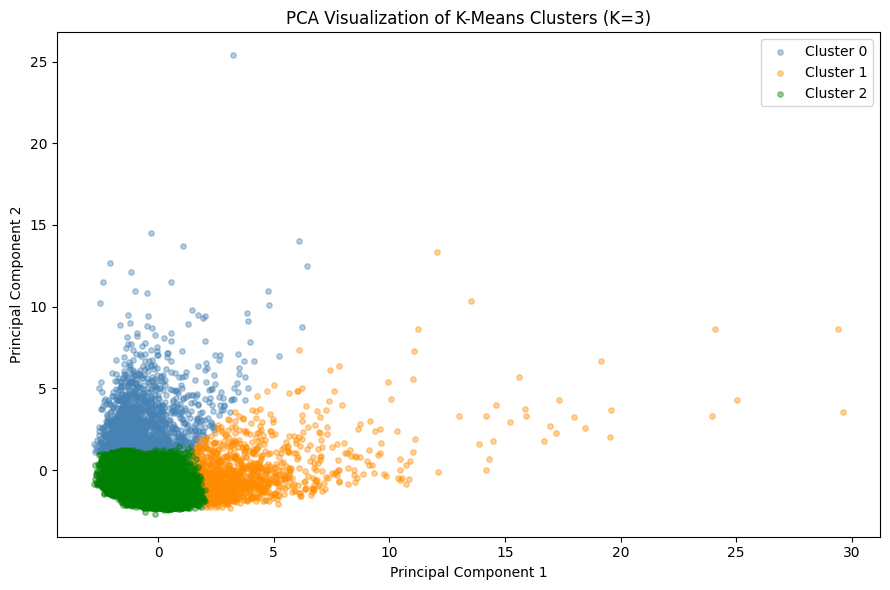

Explained variance ratio: PC1=27.29%, PC2=20.30%


In [26]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
pca_df['Cluster'] = df['Cluster'].values

plt.figure(figsize=(9, 6))
colors = ['steelblue', 'darkorange', 'green']
for cluster in sorted(pca_df['Cluster'].unique()):
    subset = pca_df[pca_df['Cluster'] == cluster]
    plt.scatter(subset['PC1'], subset['PC2'], label=f'Cluster {cluster}',
                alpha=0.4, s=15, color=colors[cluster])

plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('PCA Visualization of K-Means Clusters (K=3)')
plt.legend()
plt.tight_layout()
plt.show()

print(f'Explained variance ratio: PC1={pca.explained_variance_ratio_[0]:.2%}, PC2={pca.explained_variance_ratio_[1]:.2%}')

**Output Interpretation**

The PCA plot gives a simplified 2D view of the clusters.

If the clusters are not perfectly separated, that is normal because the original dataset has many features and the plot only shows two compressed dimensions.

## Final Questions

Answer the following questions:

1. Why is this an unsupervised learning problem?

2. Why did we remove the `CUST_ID` column?

3. Which columns had missing values?

4. How did you handle the missing values?

5. Why is scaling important before applying K-Means?

6. Which K value did you choose? Explain your answer using the elbow method and silhouette score.

7. Based on the cluster summary table, describe each customer segment in your own words.

8. Which cluster may represent high-value customers?

9. Which cluster may represent customers who rely more on cash advance?

10. How can a company use these clusters for marketing strategy?

### Answers to Final Questions

**1. Why is this an unsupervised learning problem?**

This is an unsupervised learning problem because the dataset does not contain any target label or predefined customer group. There is no column that tells us which segment a customer belongs to. We are trying to discover hidden patterns in the data on our own, without any guidance from labeled examples. K-Means clustering is an unsupervised algorithm that groups customers based purely on their behavioral similarities.

---

**2. Why did we remove the `CUST_ID` column?**

The `CUST_ID` column is just a unique identifier for each customer. It does not contain any information about customer behavior or spending habits. If we included it in clustering, it would confuse the algorithm because the IDs are arbitrary numbers that carry no meaning. Removing it ensures that the model only learns from meaningful behavioral features.

---

**3. Which columns had missing values?**

Two columns had missing values:
- `CREDIT_LIMIT`: 1 missing value
- `MINIMUM_PAYMENTS`: 313 missing values

---

**4. How did you handle the missing values?**

I used mean imputation, which means I replaced each missing value with the average value of that column. This was done using `df.fillna(df.mean(), inplace=True)`. Mean imputation is a simple and common technique that preserves the overall distribution of the data without removing any rows.

---

**5. Why is scaling important before applying K-Means?**

K-Means works by calculating distances between data points. If the features have very different scales, features with larger values (like `BALANCE` or `CREDIT_LIMIT` which can reach thousands) will dominate the distance calculations compared to features with smaller values (like frequency columns that range between 0 and 1). This would make the clustering biased toward certain features. Scaling with StandardScaler transforms all features to have a mean of 0 and a standard deviation of 1, so every feature contributes equally to the distance calculation.

---

**6. Which K value did you choose? Explain your answer using the elbow method and silhouette score.**

I chose **K = 3**.

- **Elbow method**: The elbow curve shows that inertia drops sharply from K=1 to K=3, and then the rate of decrease slows down noticeably after K=3. This suggests that adding more than 3 clusters does not bring significant improvement.
- **Silhouette score**: Among all tested values from K=2 to K=10, K=3 gives the highest silhouette score of **0.2506**. A higher silhouette score means that the clusters are better separated and more internally cohesive.
- **Business sense**: Three clusters also make intuitive sense for customer segmentation — it allows the company to distinguish between meaningfully different types of customers (cash advance users, active purchasers, and low-activity customers).

---

**7. Based on the cluster summary table, describe each customer segment in your own words.**

Based on the cluster summary with K=3:

- **Cluster 0 — Cash Advance-Reliant Customers**: These customers have a high balance (~3989) and very high cash advance usage (~3870). Their purchases are relatively low (~385). They seem to rely heavily on cash advances rather than making regular purchases. This group carries financial risk.

- **Cluster 1 — Active Purchasers / High-Value Customers**: These customers have moderate balance (~2220) but very high purchases (~4269) and high payments (~4151). They actively use their credit cards for purchases and pay their bills regularly. They have the highest credit limit (~7734), which reflects their trustworthiness.

- **Cluster 2 — Low-Activity Customers**: This is the largest group (~6119 customers). They have a low balance (~800), low purchases (~506), low cash advance (~330), and low payments (~910). These customers use their credit cards very little and have lower credit limits (~3270). They are largely inactive.

---

**8. Which cluster may represent high-value customers?**

**Cluster 1** represents high-value customers. They have the highest purchase amounts (~4269), the highest credit limits (~7734), and the highest payments (~4151). These customers are actively using their cards for purchases and paying their balances, which makes them valuable and lower-risk clients for the bank.

---

**9. Which cluster may represent customers who rely more on cash advance?**

**Cluster 0** represents customers who rely heavily on cash advance. Their average cash advance is ~3870, which is by far the highest among all clusters. Their purchases are relatively low (~385). This group carries a high balance and high minimum payments, which suggests they may be financially stressed and use cash advances frequently to cover their expenses.

---

**10. How can a company use these clusters for marketing strategy?**

The company can design different strategies for each cluster:

- **Cluster 0 (Cash Advance Users)**: Offer financial counseling, lower interest rate products, or installment loan alternatives to reduce their dependence on cash advances. Monitor this group closely for credit risk and potential defaults.

- **Cluster 1 (Active Purchasers)**: Reward them with loyalty programs, cashback offers, travel rewards, and premium card upgrades. These are the most valuable customers and should be retained through personalized incentives.

- **Cluster 2 (Low-Activity Customers)**: Send targeted promotions, spending challenges, or welcome bonus offers to encourage them to use their cards more. Since this is the largest group, even a small increase in their engagement could significantly increase overall revenue.